## Week 7 → Week 8 Transition

1. **Main Week 7 output**: I properly tested my Week 6 Random Forest by tuning it, tried a new model (Gradient Boosting), ran a threshold sweep, checked performance across Data Analytics' key segments, and resolved the open cross-track disagreement with Data Analytics team Yusuf over no-show rates.

2. **Most important testing result**: Gradient Boosting looked like it beat the baseline on recall (0.64 vs 0.62) at the default 0.5 threshold, but 5-fold cross-validation at that same threshold showed the two models are actually statistically tied (baseline 0.625 ± 0.013, GB 0.627 ± 0.009). I had to withdraw the GB is better claim i initially claimed.

3. **Major issue discovered**: Model choice for Week 8 is still open. Recall alone can't decide between baseline and GB anymore. I also found the model performs noticeably worse on two segments which are Specialist Consultation appointments and WhatsApp-reminder patients.

4. **What was refined/improved**: Tuning reduced the Random Forest's overfitting. I corrected an earlier mistake, the "high age importance" I reported in Week 6 was actually from the untuned model because the tuned figure (0.138) is more modest but still real. I picked GB as my working candidate not for accuracy but because its errors overlap more with the baseline's (easier to explain) and it makes sense slightly better. I also resolved the 70.5% vs 64.1% no-show rate gap with Data Analysis team Yusuf. The disagreement was as a result of using different labels in the lead time cut offs

5. **Component now considered ready**: The tested Gradient Boosting model, run at the 0.4 threshold (recall 0.81, precision 0.57) rather than the default 0.5, with a documented error analysis is ready to serve as this week's starting point, pending a final locked-in model decision. 

6. **What still needs to be integrated**: A final choice between baseline and GB (using criteria beyond recall), and that decision needs to be handed off to ML Engineering along with the threshold. The two weak segments also still need a decision on how to handle them.

7. **Track(s) involved in final integration**: Data Science (mine), Data Analytics (segment and no-show rate validation), and ML Engineering (who will receive the final model and threshold).

8. **What I intend to demonstrate in the final presentation**: How rigorous testing especially cross-validation caught a false lead before it became a wrong conclusion, and that my final model choice is better based on evidence.

## Part 1 — Final Integration Readiness

**What is my final component?**
A no-show prediction model Gradient Boosting, tuned to a 0.4 decision threshold. The final choice vs. the Week 5 baseline logistic regression is pending the precision comparison at 0.4.

**What problem does it address?**
Predicting which patients are likely to miss their appointment, so HealthConnect can intervene (reminders, overbooking) before the slot is wasted.

**What is its current status?**
Tested and tuned at threshold of 0.4 (recall 0.81, precision 0.57), documentation of error analysis is complete. However, choice not yet finalized.

**What did I improve during Week 7?**
Tuned the Random Forest (reduced overfitting), tested Gradient Boosting as an alternative, ran a 5-fold cross-validation that caught a false lead (GB's apparent recall edge didn't hold up), ran a threshold sweep, checked performance across Data Analytics' key segments, corrected an earlier feature-importance error (age: 0.202 untuned → 0.138 tuned), resolved the no-show rate discrepancy with Data Analyst Yusuf.

**Which other track(s) does it depend on?**
Data Analytics: for segment definitions and validated no-show patterns.

**Which track(s) depend on my output?**
ML Engineering: needs the final model and threshold to build the pipeline.

**What output will I provide?**
Final model object, chosen decision threshold, evaluation metrics (baseline vs. final), error analysis and documented limitations.

**What output do I need from another track?**
Confirmation from Data Analytics that Specialist Consultation and WhatsApp-reminder segments show distinct patterns in their own validated analysis. This is to cross-check whether the model's weak spot reflects a real underlying pattern or is specific to my model. Also, confirmation from ML Engineering on pipeline constraints (model type, expected output format and any latency/dependency requirements) before the model choice is locked in.S

**What evidence demonstrates readiness?**
Cross-validation results, threshold sweep, segment-level performance breakdown, error analysis (shared false negatives with baseline), resolved no-show rate discrepancy log.

**What limitations remain?**
Model choice not yet locked (pending baseline-vs-GB comparison); weaker performance on Specialist Consultation and WhatsApp-reminder segments (currently under investigation), unresolved train-test gap in both candidate models and that no feature currently explains the first-time-patient blind spot.

## Final Model Selection: Baseline vs. Gradient Boosting at Matched Threshold

### Loading Baseline Model & Test Data

In [1]:
import pandas as pd
import joblib

X_test = pd.read_csv("week6_X_test.csv")
y_test = pd.read_csv("week6_y_test.csv").squeeze()
gb_model = joblib.load("week7_gradient_boosting_model.pkl")
baseline_model = joblib.load("week5_baseline_model.pkl")

In [2]:
baseline_model

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

### Note: Feature Mismatch Discovered During Comparison

While preparing the baseline vs. GB comparison at the 0.4 threshold, I discovered the two models can't be fairly compared as it is. The Week 5 baseline was trained on 14 features, while GB (and the data since Week 6) uses 18 features. Four engineered features were added in Week 6 (`had_prior_noshow`, `recent_booking_flag`, `recent_and_sms`, `lead_and_prior_noshow`), these were never part of the baseline's training set.

This means any recall/precision gap between the two models wouldn't isolate the algorithm. It would also reflect the extra features GB has and the baseline doesn't, which is a confound, not a fair comparison.

Notably, this isn't a case of the features never being tested, all four were included in Week 6's refined Logistic Regression and Random Forest. Only `recent_and_sms` and `lead_and_prior_noshow` were individually t-tested before being added. `had_prior_noshow` and `recent_booking_flag` were intermediate flags built to construct those two interaction terms. Even with all four features present, the refined Logistic Regression didn't beat the Week 5 baseline (recall 0.61 vs 0.62) but the Week 5 baseline itself has never been evaluated with these features, which is the actual gap this retrain closes.

**Resolution:** retraining the baseline logistic regression on the same 18-feature set GB uses, to get the same feature comparison

In [3]:
baseline_model.feature_names_in_

array(['age', 'booking_lead_days', 'previous_appointments',
       'previous_no_shows', 'distance_to_clinic_km',
       'is_first_time_patient', 'prior_no_show_rate',
       'appointment_type_Follow-up',
       'appointment_type_General Consultation',
       'appointment_type_Specialist Consultation', 'reminder_sent_Yes',
       'reminder_channel_No Reminder', 'reminder_channel_SMS',
       'reminder_channel_WhatsApp'], dtype=object)

### Retraining Baseline Logistic Regression

In [4]:
X_train = pd.read_csv("week6_X_train.csv")
y_train = pd.read_csv("week6_y_train.csv").squeeze()

In [5]:
from sklearn.linear_model import LogisticRegression

baseline_full = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
baseline_full.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [6]:
baseline_full_probs = baseline_full.predict_proba(X_test)[:, 1]

In [7]:
baseline_full_pred = (baseline_full_probs >= 0.4).astype(int)

In [8]:
from sklearn.metrics import recall_score, precision_score

baseline_full_recall = recall_score(y_test, baseline_full_pred)
baseline_full_precision = precision_score(y_test, baseline_full_pred)

print("Recall:", baseline_full_recall)
print("Precision:", baseline_full_precision)

Recall: 0.8033126293995859
Precision: 0.5825825825825826


### Final Comparison: Baseline (18 features) vs. Gradient Boosting at Matched Threshold

| Model | Features | Threshold | Recall | Precision |
|---|---|---|---|---|
| Logistic Regression (retrained) | 18 | 0.4 | 0.803 | 0.583 |
| Gradient Boosting | 18 | 0.4 | 0.81 | 0.57 |

**Interpretation:** Once the baseline was retrained on the same 18 features GB uses, the earlier apparent GB advantage disappears. Recall differs by just 0.007 and precision by 0.013, both well within normal variation. This confirms, more definitively than the Week 7 cross-validation result, that GB does not meaningfully outperform logistic regression on this dataset once the comparison is fair.

Given performance is effectively tied, the deciding factor becomes model simplicity rather than raw metrics. Logistic regression is easier to explain to non-technical stakeholders and to ML Engineering, and there's no clear performance justification for the added complexity of a tree-based ensemble when a simpler model performs just as well.

**Next step:** checking the baseline's train-test gap (recall on training data vs. test data) to compare against GB's generalization behavior (0.07 gap) before making the final call.

In [9]:
baseline_train_probs = baseline_full.predict_proba(X_train)[:, 1]
baseline_train_pred = (baseline_train_probs >= 0.4).astype(int)
baseline_train_recall = recall_score(y_train, baseline_train_pred)

print("Train recall:", baseline_train_recall)
print("Test recall:", baseline_full_recall)
print("Gap:", baseline_train_recall - baseline_full_recall)

Train recall: 0.8072164948453608
Test recall: 0.8033126293995859
Gap: 0.0039038654457749233


**Interpretation:**

The retrained baseline's train-test gap (0.004) is way smaller than Gradient Boosting's (0.07), more than 17 times smaller. This means the baseline's test performance is a reliable estimate of how it will behave on new patients, while GB relies more on patterns specific to the training data.

Combined with recall and precision being effectively tied between the two models (0.803/0.583 vs 0.81/0.57), there is no longer a performance-based case for GB's added complexity. Logistic regression matches GB on the metrics that matter, generalizes more reliably, and is easier to explain to ML Engineering and non-technical stakeholders.

**Decision:** The retrained Logistic Regression (18 features, threshold 0.4) is selected as the model going forward, replacing Gradient Boosting. The known weakness on Specialist Consultation and WhatsApp-reminder segments is unresolved and remains a separate open limitation.

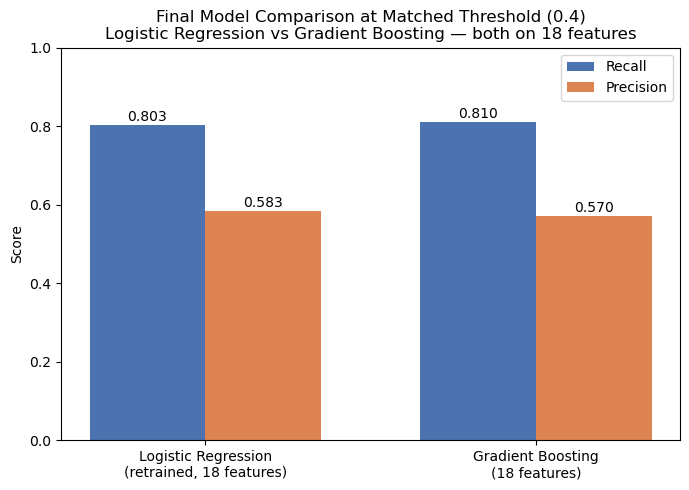

In [10]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Logistic Regression\n(retrained, 18 features)', 'Gradient Boosting\n(18 features)']
recall_vals = [0.803, 0.81]
precision_vals = [0.583, 0.57]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - width/2, recall_vals, width, label='Recall', color='#4C72B0')
bars2 = ax.bar(x + width/2, precision_vals, width, label='Precision', color='#DD8452')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)

ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.set_title('Final Model Comparison at Matched Threshold (0.4)\nLogistic Regression vs Gradient Boosting — both on 18 features')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=150)
plt.show()

### Error Analysis Summary

In [11]:
X_test_full = X_test.copy()
X_test_full['actual'] = y_test.values
X_test_full['predicted'] = baseline_full_pred

false_negatives = X_test_full[(X_test_full['actual'] == 1) & (X_test_full['predicted'] == 0)]
true_positives = X_test_full[(X_test_full['actual'] == 1) & (X_test_full['predicted'] == 1)]

print("False negatives (missed no-shows):", len(false_negatives))
print("True positives (caught no-shows):", len(true_positives))

False negatives (missed no-shows): 95
True positives (caught no-shows): 388


In [12]:
compare_cols = ['reminder_sent_Yes', 'reminder_channel_SMS', 'reminder_channel_WhatsApp',
                'reminder_channel_No Reminder', 'is_first_time_patient', 
                'prior_no_show_rate', 'booking_lead_days']

print("False negatives (missed no-shows):")
print(false_negatives[compare_cols].mean())
print()
print("True positives (caught no-shows):")
print(true_positives[compare_cols].mean())

False negatives (missed no-shows):
reminder_sent_Yes               0.800000
reminder_channel_SMS            0.515789
reminder_channel_WhatsApp       0.178947
reminder_channel_No Reminder    0.200000
is_first_time_patient           0.073684
prior_no_show_rate              0.266018
booking_lead_days              -0.501868
dtype: float64

True positives (caught no-shows):
reminder_sent_Yes               0.698454
reminder_channel_SMS            0.360825
reminder_channel_WhatsApp       0.213918
reminder_channel_No Reminder    0.301546
is_first_time_patient           0.041237
prior_no_show_rate              0.598788
booking_lead_days               0.335052
dtype: float64


In [13]:
from scipy import stats

lead_stat, lead_pval = stats.ttest_ind(false_negatives['booking_lead_days'], true_positives['booking_lead_days'])
noshow_stat, noshow_pval = stats.ttest_ind(false_negatives['prior_no_show_rate'], true_positives['prior_no_show_rate'])

print("Booking lead days — t-statistic:", lead_stat, "p-value:", lead_pval)
print("Prior no-show rate — t-statistic:", noshow_stat, "p-value:", noshow_pval)

Booking lead days — t-statistic: -17.527488598871145 p-value: 1.5030481393046854e-53
Prior no-show rate — t-statistic: -4.040886713334945 p-value: 6.198277283575542e-05


This track's error analysis has been an ongoing thread across Weeks 6–8, revisited each week as the model changed.

**Week 6 (original baseline, 14 features):** Missed no-shows (false negatives) were found to look "safe" on paper, more likely to have received a reminder (especially SMS) and less concentrated among patients with long lead times or a history of prior no-shows, the opposite of the profile the model was best at catching.

**Week 7 (Gradient Boosting vs baseline):** A different angle on the same limitation was found: false negatives shared by both models were concentrated in first-time patients with no prior no-show history, with lead times that weren't extreme either way. This pointed to a data/feature gap rather than an algorithm-choice problem, since it held regardless of which model was used.

**Week 8 (final model, `baseline_full`, 18 features):** The Week 6 pattern was formally retested on the actual final model, not assumed to still hold. Comparing false negatives (n=95) to true positives (n=388) confirmed both `booking_lead_days` (t = -17.53, p < 0.0001) and `prior_no_show_rate` (t = -4.04, p < 0.0001) differ significantly between the two groups — missed no-shows book more recently and have cleaner histories than caught no-shows, statistically confirming the Week 6 finding rather than just carrying it forward by assumption.

**Segment-level continuation:** Week 8 also extended the error analysis by checking whether errors cluster in specific segments (see below). Specialist Consultation's recall gap was tested and ruled out as sample noise (p=0.111), while the WhatsApp-reminder precision gap was confirmed real (p=0.037) but its cause remains unexplained.

**Overall pattern:** Across all three weeks and two different models, the model's core weakness has stayed consistent: it reliably catches "obviously risky" no-shows (long lead time, prior no-show history, no reminder) but is blind to patients who look low-risk on paper, especially first-time patients and those who received a reminder shortly before their appointment. This is treated as a data/feature limitation rather than something further model tuning can fix.

### Segment Performance Check — Final Model (Logistic Regression)

In [14]:
X_test.columns.tolist()

['age',
 'booking_lead_days',
 'previous_appointments',
 'previous_no_shows',
 'distance_to_clinic_km',
 'is_first_time_patient',
 'prior_no_show_rate',
 'had_prior_noshow',
 'recent_booking_flag',
 'recent_and_sms',
 'lead_and_prior_noshow',
 'appointment_type_Follow-up',
 'appointment_type_General Consultation',
 'appointment_type_Specialist Consultation',
 'reminder_sent_Yes',
 'reminder_channel_No Reminder',
 'reminder_channel_SMS',
 'reminder_channel_WhatsApp']

In [15]:
spec_mask = X_test['appointment_type_Specialist Consultation'] == 1

In [16]:
spec_mask.sum()

np.int64(180)

In [17]:
spec_recall = recall_score(y_test[spec_mask], baseline_full_pred[spec_mask])
print("Specialist Consultation recall:", spec_recall)

Specialist Consultation recall: 0.7446808510638298


In [18]:
rest_recall = recall_score(y_test[~spec_mask], baseline_full_pred[~spec_mask])
print("Rest of data recall:", rest_recall)

Rest of data recall: 0.8174807197943444


In [19]:
whatsapp_mask = X_test['reminder_channel_WhatsApp'] == 1
whatsapp_mask.sum()

np.int64(212)

In [20]:
whatsapp_precision = precision_score(y_test[whatsapp_mask], baseline_full_pred[whatsapp_mask])
print("WhatsApp precision:", whatsapp_precision)

WhatsApp precision: 0.5123456790123457


In [21]:
rest_whatsapp_precision = precision_score(y_test[~whatsapp_mask], baseline_full_pred[~whatsapp_mask])
print("Rest of data precision:", rest_whatsapp_precision)

Rest of data precision: 0.6051587301587301


### Segment Performance Check — Specialist Consultation & WhatsApp Reminder

| Segment | Metric | In-segment | Rest of data | Gap |
|---|---|---|---|---|
| Specialist Consultation (n=180) | Recall | 0.745 | 0.817 | 7 points |
| WhatsApp reminder (n=212) | Precision | 0.512 | 0.605 | 9 points |

Both segments show a visible performance drop relative to the rest of the test set. Specialist Consultation appointments have lower recall, meaning more actual no-shows are missed in this group. WhatsApp-reminder patients have lower precision, meaning more of the model's no-show flags are wrong for this group. Whether these gaps reflect a real, meaningful pattern or fall within normal sample variation (segment sizes of 180 and 212 are moderate but not large) is checked next with a statistical significance test.

In [22]:
from sklearn.metrics import confusion_matrix

spec_cm = confusion_matrix(y_test[spec_mask], baseline_full_pred[spec_mask])
print(spec_cm)

[[39 47]
 [24 70]]


In [23]:
rest_cm = confusion_matrix(y_test[~spec_mask], baseline_full_pred[~spec_mask])
print(rest_cm)

[[166 231]
 [ 71 318]]


In [24]:
from statsmodels.stats.proportion import proportions_ztest

In [25]:
spec_caught = [70, 318]
spec_actual_noshows = [94, 389]

stat, pval = proportions_ztest(spec_caught, spec_actual_noshows)
print("z-statistic:", stat)
print("p-value:", pval)

z-statistic: -1.593548271590783
p-value: 0.11103724837003287


In [26]:
from sklearn.metrics import confusion_matrix

whatsapp_cm = confusion_matrix(y_test[whatsapp_mask], baseline_full_pred[whatsapp_mask])
print(whatsapp_cm)

[[33 79]
 [17 83]]


In [27]:
rest_cm1 = confusion_matrix(y_test[~whatsapp_mask], baseline_full_pred[~whatsapp_mask])
print(rest_cm1)

[[172 199]
 [ 78 305]]


In [28]:
from statsmodels.stats.proportion import proportions_ztest
whatsapp_caught = [83, 305]
whatsapp_actual_noshows = [162, 504]

stat1, pval1 = proportions_ztest(whatsapp_caught, whatsapp_actual_noshows)
print("z-statistic:", stat1)
print("p-value:", pval1)

z-statistic: -2.083918255971303
p-value: 0.03716760345433727


### Segment Performance Check — Statistical Significance

| Segment | Metric | In-segment | Rest of data | Gap | z-statistic | p-value | Significant? |
|---|---|---|---|---|---|---|---|
| Specialist Consultation (n=180) | Recall | 0.745 | 0.817 | 7 points | -1.594 | 0.111 | No |
| WhatsApp reminder (n=212) | Precision | 0.512 | 0.605 | 9 points | -2.084 | 0.037 | Yes |

The two flagged segments turned out differently under testing. Specialist Consultation's recall gap is not statistically significant (p=0.111), the sample size (94 actual no-shows) is small enough that this gap is plausibly due to normal variation rather than a genuine model weakness. WhatsApp's precision gap, however, is statistically significant (p=0.037), meaning the model is genuinely less precise for this segment, not by chance.

**Decision**: The Specialist Consultation gap isn't strong enough to call a real weakness yet, it's worth keeping an eye on, but doesn't need fixing right now. The WhatsApp gap is real, so the next step is figuring out why it's happening

#### What's Driving the WhatsApp Precision Gap?

Checking whether the WhatsApp segment's false positives (patients wrongly flagged as no-show) differ from its true positives (correctly flagged) on the features known to matter most to the model and they are is_first_time_patient, prior_no_show_rate and booking_lead_days.

In [29]:
X_test_wa = X_test[whatsapp_mask].copy()
X_test_wa['actual'] = y_test[whatsapp_mask].values
X_test_wa['predicted'] = baseline_full_pred[whatsapp_mask]

In [30]:
whatsapp_fp = X_test_wa[(X_test_wa['actual'] == 0) & (X_test_wa['predicted'] == 1)]
whatsapp_tp = X_test_wa[(X_test_wa['actual'] == 1) & (X_test_wa['predicted'] == 1)]

print("False positives:", len(whatsapp_fp))
print("True positives:", len(whatsapp_tp))

False positives: 79
True positives: 83


In [31]:
compare_cols = ['is_first_time_patient', 'prior_no_show_rate', 'booking_lead_days']

print("False positives (wrongly flagged):")
print(whatsapp_fp[compare_cols].mean())
print()
print("True positives (correctly flagged):")
print(whatsapp_tp[compare_cols].mean())

False positives (wrongly flagged):
is_first_time_patient    0.037975
prior_no_show_rate       0.466365
booking_lead_days        0.140057
dtype: float64

True positives (correctly flagged):
is_first_time_patient    0.024096
prior_no_show_rate       0.606627
booking_lead_days        0.280606
dtype: float64


In [32]:
from scipy import stats

lead_stat, lead_pval = stats.ttest_ind(whatsapp_fp['booking_lead_days'], whatsapp_tp['booking_lead_days'])
noshow_stat, noshow_pval = stats.ttest_ind(whatsapp_fp['prior_no_show_rate'], whatsapp_tp['prior_no_show_rate'])

print("Booking lead days — t-statistic:", lead_stat, "p-value:", lead_pval)
print("Prior no-show rate — t-statistic:", noshow_stat, "p-value:", noshow_pval)

Booking lead days — t-statistic: -1.9680977086606342 p-value: 0.05078502761014102
Prior no-show rate — t-statistic: -1.1623536520479814 p-value: 0.24682266931966174


In [33]:
fp_first_time = whatsapp_fp['is_first_time_patient'].sum()
tp_first_time = whatsapp_tp['is_first_time_patient'].sum()

first_time_stat, first_time_pval = proportions_ztest(
    [fp_first_time, tp_first_time],
    [len(whatsapp_fp), len(whatsapp_tp)]
)
print("is_first_time_patient — z-statistic:", first_time_stat, "p-value:", first_time_pval)

is_first_time_patient — z-statistic: 0.5105184939568241 p-value: 0.609688261389973


#### Result: What's Driving the WhatsApp Precision Gap?

| Feature | Test | p-value | Significant? |
|---|---|---|---|
| booking_lead_days | t-test | 0.051 | Borderline (no) |
| prior_no_show_rate | t-test | 0.247 | No |
| is_first_time_patient | proportions z-test | 0.610 | No |

 None of the three features known to drive the model's overall behavior, is_first_time_patient, prior_no_show_rate, and booking_lead_days, statistically explain why WhatsApp's false positives differ from its true positives. booking_lead_days comes close (p=0.051), just missing the standard 0.05 cutoff, and is worth noting as a borderline value but it doesn't meet the bar for a confirmed driver. The other two features show no meaningful difference between the two groups.

**Decision:** The WhatsApp precision gap (confirmed as statistically real above) cannot currently be explained by the model's known strongest features. This is logged as an open limitation for Week 8, the gap is real, but its cause is not yet understood with the data and features available.

### Final Decision 
The final model for Week 8 is Logistic Regression at a threshold of 0.4. This is because, compared to Gradient Boosting, it is tied on recall (0.803 vs 0.81) and precision (0.583 vs 0.57), is more trustworthy based on the train-test gap found (0.004 vs GB's 0.07) and is simpler to explain to ML Engineering and non-technical stakeholders. Choosing this means giving up any non-linear relationships or feature interactions that Gradient Boosting might in principle pick up but Logistic Regression, being a linear model, cannot.

### Model Strenghts and Weakness


**Strengths:**

The final Logistic Regression model catches the large majority of patients likely to miss their appointment (recall = 0.803), which is the priority for HealthConnect's intervention use case, better to flag a patient than miss them. On the metrics that matter, Logistic Regression is close enough to Gradient Boosting that neither model has a clear edge (recall 0.803 vs 0.81, precision 0.583 vs 0.57). What separates them is reliability and simplicity: Logistic Regression's train-test gap (0.004) is roughly 17 times smaller than GB's (0.07), meaning its test-set performance is a trustworthy estimate of how it will behave on new patients. It is also simpler to explain to ML Engineering and non-technical stakeholders than a tree-based model.

**Weaknesses:**

Recall comes at a precision cost of 0.583, roughly 4 in 10 patients flagged as likely no-shows will actually attend, meaning any intervention (reminder calls, overbooking) will sometimes target patients who didn't need it. Being linear, the model also cannot capture non-linear relationships or feature interactions the way GB could in principle. Its one confirmed weakness is a statistically significant precision drop for WhatsApp-reminder patients (p=0.037), the cause of which remains unexplained even after testing the model's three strongest features; the apparent recall gap for Specialist Consultation appointments was tested and ruled out as sample-size noise (p=0.111).

### Business Suitability

The Logistic Regression model is suitable for HealthConnect Clinic's goal of reducing missed appointments and improving the patient support experience, but only for low-cost interventions like reminder calls or SMS. This is because precision is 0.583, roughly 4 in 10 patients flagged as likely no-shows will actually attend, so a wrong flag should carry a low cost, an unnecessary reminder, rather than a high one.

The model is not currently suitable for high-cost actions like overbooking or reassigning a flagged patient's slot. At this precision level, doing so would double-book a genuinely attending patient nearly 4 times in 10, risking the exact scheduling conflict the clinic is trying to avoid, just shifted onto a different patient rather than solved. Overbooking based on no-show prediction is a legitimate strategy in healthcare more broadly, but adopting it here would need either a higher-precision model or an explicit, deliberate decision by HealthConnect that the trade-off (occasional double-booking vs. guaranteed empty slots) is worth making.

### Model Summary for Non-Technical Stakeholders

We built a tool that predicts which patients are likely to miss their upcoming appointment, so the clinic can act before the slot goes to waste.

Out of every 10 patients who will actually miss their appointment, the tool correctly flags about 8 of them. That's its main strength, it rarely lets a no-show slip through unnoticed.

The trade-off is accuracy on the flip side. Of every 10 patients the tool flags as likely no-shows, only about 6 will actually miss their appointment, the other 4 would have shown up. Because of this, the tool should only be used for low-cost follow-up, like sending an extra reminder call or text. It should not be used to double-book a flagged patient's slot, since that risks turning away a patient who was always going to come.

The tool currently works less reliably for two groups, patients being reminded through WhatsApp, and patients with no prior visit history. Both are known gaps that would need further investigation before the tool is fully relied on for those groups.

In short, this is a solid first step for reducing missed appointments through better reminders, not yet a tool for reshuffling clinic slots.

### Cross-Track Contribution — Data Analytics (zakheni)

**Track collaborated with:** Data Analytics (zakheni)

**Dependency:** Data Science's Week 8 model finalization could be strengthened by validated no-show findings and candidate variables from the Analytics track.

**Output received:** zakheni shared validated findings (overall no-show rate 48.46%, distance and reminder-status breakdowns, previous no-show history pattern) and a candidate variable list (previous no-shows, previous appointments, reminder status, distance to clinic, waiting time, appointment type, age group, booking lead days).

**Output provided:** Cross-checked the candidate list against the current 18-feature model — previous no-shows, previous appointments, reminder status, distance to clinic, appointment type, and booking lead days are already active features; age is used as a continuous variable rather than age_group. Also flagged that the model underperforms specifically on WhatsApp-reminder patients, prompting a joint investigation.

**Final integration activity:** zakheni produced a reminder-channel breakdown (WhatsApp 49.77%, SMS 45.75%, Email 48.41%, No Reminder 51.39% no-show rate) to help investigate the WhatsApp precision gap, which ruled out "WhatsApp patients have unusually high real-world no-show rates" as the explanation. This was combined with two checks from this track's own prior work: this track's Week 5 finding that `reminder_channel` missingness aligns with `reminder_sent = No` (ruling out a missing-data explanation) and a sample-size comparison against a segment already ruled out as noise.

**What changed / evidence:** Three plausible causes for the WhatsApp precision gap were tested and ruled out — one using this track's own prior findings, one jointly with Data Analytics' channel breakdown, one independently. The gap remains statistically significant (p=0.037) with an unidentified cause, documented as an open limitation rather than a resolved issue.

**How the change improved the solution:** Turns an unexplained model weak spot into a documented, evidence-tested limitation rather than a guess, giving ML Engineering and HealthConnect an honest account of where the model underperforms and why three likely causes don't explain it.

**Contribution to the final presentation:** Evidence for the "Testing, Refinement & Final Outcome" section of the video, a real cross-track investigation into a confirmed model weakness, not just a reported number.

#### Investigating the Distance-to-Clinic Disagreement with Claudia

In [34]:
from scipy import stats

distance_corr, distance_pval = stats.pointbiserialr(y_test, X_test['distance_to_clinic_km'])
print("Point-biserial correlation:", distance_corr)
print("p-value:", distance_pval)

Point-biserial correlation: 0.03868961702837882
p-value: 0.22960108512792152


During Week 6 cross-track collaboration, Claudia (Data Analytics) reported no correlation between `distance_to_clinic_km` and no-shows, while this track's Random Forest ranked `distance_to_clinic_km` as its single most important feature. A point-biserial correlation was run between `distance_to_clinic_km` and the actual outcome (`y_test`) to check whether this was a real contradiction.

**Result:** correlation = 0.039, p = 0.230 , negligible and not statistically significant. This confirms Claudia's finding that distance does not move up or down together with no-shows in any simple, straight-line way.

**Resolution:** this is not a contradiction, because correlation and feature importance are answering two different questions. Correlation only checks for a simple straight-line relationship does no-show consistently increase or decrease as distance increases. Feature importance checks something broader like does distance help the model make better predictions at all, in any way, even a complicated one? A Random Forest can find patterns correlation can't see, for example, distance only mattering for certain appointment types, or only past a certain distance threshold, or only in combination with other features. Those patterns would not show up as a correlation, but the model can still use them heavily when predicting. So distance failed the simple straight-line test but passed the "is it useful for prediction" test, both findings were correct, they were just measuring different things.

### Cross-Track Contribution — Data Analytics (Claudia)

**Track collaborated with:** Data Analytics (Claudia)

**Dependency:** Data Science's model development could be strengthened by validated no-show patterns and feature ideas from the Analytics track; Claudia requested this track's final feature list, feature importance results, and `reminder_channel` handling approach for her own analysis.

**Output received:** Claudia shared her strongest observed pattern that patients with no `reminder_channel` set had a much higher no-show rate — along with her own `reminder_channel` handling (grouping missing values into a "No Reminder" category, the same approach used on this track), her dataset's overall no-show rate (48.46%), and a note that she found no correlation between `distance_to_clinic_km` and no-shows in her own analysis.

**Output provided:** Shared the final 18-feature list, Random Forest feature importance ranking (`distance_to_clinic_km`, `booking_lead_days`, `age`, `previous_appointments`, `prior_no_show_rate` as top features), and `reminder_channel` handling. Tested Claudia's reminder-channel pattern against this track's data and found a smaller effect than reported (5-point gap in no-show rate, not a near-universal pattern), traced the difference in missing-value counts (1,285 here vs. 1,633 on her side) to this track's exclusion of 263 Cancelled appointments before analysis, which she had kept in.

**What changed / evidence:** Claudia's correlation finding on `distance_to_clinic_km` conflicted with this track's Random Forest ranking it as the single most important feature. A point-biserial correlation check (r = 0.039, p = 0.230) confirmed Claudia was correct that no simple linear relationship exists but showed this doesn't contradict the model's feature importance result, since a Random Forest can pick up non-linear or interaction-based patterns that a correlation coefficient can't detect. Documented as a resolved cross-track disagreement, not an open limitation.

**How the change improved the solution:** Resolved an apparent contradiction between two tracks' findings on the same feature, closing out a limitation that had been open since Week 7 and confirming `distance_to_clinic_km` is safe to keep in the model despite showing no simple correlation with the outcome.

**Contribution to the final presentation:** Demonstrates cross-track collaboration resolving a genuine data disagreement with evidence rather than assumption, for the presentation's cross-track collaboration segment.

In [35]:
import pandas as pd

df = pd.read_csv("HealthConnect_ML_Processed.csv")
df['reminder_channel'] = df['reminder_channel'].fillna('No Reminder')

short_notice = df[df['booking_lead_days'] <= 7]

noshow_rate_by_channel = short_notice.groupby('reminder_channel')['appointment_outcome'].mean()

sample_sizes = short_notice.groupby('reminder_channel').size()

print("No-show rate by reminder channel (0-7 day lead time):")
print(noshow_rate_by_channel)
print()
print("Sample sizes:")
print(sample_sizes)

No-show rate by reminder channel (0-7 day lead time):
reminder_channel
Email          0.210526
No Reminder    0.312500
SMS            0.295276
WhatsApp       0.324561
Name: appointment_outcome, dtype: float64

Sample sizes:
reminder_channel
Email           76
No Reminder    160
SMS            254
WhatsApp       114
dtype: int64


In [36]:
from statsmodels.stats.proportion import proportions_ztest

email_noshows = short_notice[short_notice['reminder_channel'] == 'Email']['appointment_outcome'].sum()
sms_noshows = short_notice[short_notice['reminder_channel'] == 'SMS']['appointment_outcome'].sum()

email_n = (short_notice['reminder_channel'] == 'Email').sum()
sms_n = (short_notice['reminder_channel'] == 'SMS').sum()

stat, pval = proportions_ztest([email_noshows, sms_noshows], [email_n, sms_n])

print("Email no-shows:", email_noshows, "/", email_n)
print("SMS no-shows:", sms_noshows, "/", sms_n)
print("z-statistic:", stat)
print("p-value:", pval)

Email no-shows: 16 / 76
SMS no-shows: 75 / 254
z-statistic: -1.4504306488101062
p-value: 0.14693846549506517


### Cross-Track Contribution — Data Analytics (Angela)

**Track collaborated with:** Data Analytics (Iseriehen Angela)

**Dependency:** Data Science's model development could be strengthened by validated interaction patterns from the Analytics track that individual feature testing might not capture; Angela requested this track's Week 5 baseline results and feature list to identify gaps.

**Output received:** Angela reviewed this track's actual Week 5 notebook and shared two evidence-backed interaction findings: (1) booking lead time and prior no-show history compound rather than act independently. no-show rate ranges from 21.8% to 67.9% depending on the combination, validated as consistent across all appointment types in her analysis
(2) reminder channel effectiveness depends on lead time — SMS performs best overall, but Email outperforms it for short-notice (0-7 day) appointments, and SMS barely beats No Reminder in that same window.

**Output provided:** This track's finalized feature list, Random Forest feature importance ranking, and an explanation of `reminder_channel`'s missing-value handling.

**What changed / evidence:** Both of Angela's findings were tested, with different outcomes. (1) The lead-time × prior-no-show interaction was validated (consistent direction and pattern) and engineered as `lead_and_prior_noshow` (t = -14.282, p < 0.0001) — statistically significant, but did not improve model recall when added, redirecting Week 6's conclusion toward a model-level limitation rather than a missing-feature problem. 

(2) The reminder-channel × lead-time interaction went untested through Week 6 and Week 7; at final integration, it was checked directly and Email showed a lower no-show rate than SMS for short-notice appointments (21.1% vs. 29.5%, n=76 vs. n=254), matching Angela's reported direction, but a proportions z-test found the gap not statistically significant (z = -1.450, p = 0.147), most likely due to Email's smaller sample size. 

**How the change improved the solution:** Both of Angela's suggestions were carried through to a tested conclusion rather than left as open recommendations. The first directly informed the model-level-limitation conclusion and the second, untested since Week 6, was finally checked at final integration and honestly reported as direction-confirmed but not statistically proven.

**Contribution to the final presentation:** Shows the model's testing rigor and honest handling of a result that didn't fully confirm a collaborator's claim, useful for both the cross-track and testing/refinement segments of the video.

### Cross-Track Contribution — Data Analytics (Hudu Yusuf Ibrahim)

**Track collaborated with:** Data Analytics (Hudu Yusuf Ibrahim)

**Dependency:** Data Analytics' Week 6 integration record needed Data Science's model results and validation of their Chi-square/Cramér's V findings; Week 7 needed formal cross-track testing evidence confirming a numeric discrepancy between the two tracks was resolved.

**Output received:** Yusuf's Data Analytics team's validated finding that the 3+ weeks lead-time + prior no-show segment had the highest observed no-show rate (64.1%), plus a formal Week 7 validation request to confirm the denominator behind this track's own 70.5% figure for the same segment, and to re-run it with Cancelled appointments included.

**Output provided (Week 6):** Model results for all three tested models (baseline Logistic Regression, refined Logistic Regression, Random Forest — baseline strongest), Random Forest feature importance ranking, and error analysis findings (missed no-shows more likely to have received a reminder, especially SMS, than caught no-shows). Validated Yusuf's lead-time × prior-no-show finding via crosstab and confirmed the same rising pattern (23% to 70%) consistent across appointment types, though with a higher peak figure (70.5%) than his team's 64.1%.

**What changed / evidence:** The 64.1% vs 70.5% discrepancy was formally investigated at Yusuf's Week 7 request. First pass showed the two figures used different denominators. This track excluded Cancelled appointments while Yusuf's included them. Including Cancelled dropped the figure from 70.5% to 67.9%, but a 3.8 point gap to 64.1% still remained even after matching on that. The final resolution came through Yusuf's parallel cross-check with teammate Donald. The real cause turned out to be two separate definitional differences, the lead-time cutoff for "long lead time" (this track and Donald used over 30 days, Yusuf's "3+ weeks" was 22 days or more) and the Cancelled-appointments handling. Once both tracks aligned on identical criteria, the figures matched exactly (70.52% and 67.88%), confirming both sides were working from the same underlying data all along, just different segment definitions, not a data or calculation error.

**Evidence:** Slack message exchange, covering the Week 6 model-sharing and validation exchange and the Week 7 formal validation request and resolution thread.

**How the change improved the solution:** Fully resolved a numeric discrepancy between two tracks' independent findings, confirming both sides were working from consistent underlying data. This strengthens confidence in the shared no-show findings feeding into HealthConnect's final recommendations.

**Contribution to the final presentation:** Evidence of a rigorous, multi-round cross-track validation process for the presentation's cross-track collaboration segment.

### Cross-Track Contribution — ML Engineering

**Track collaborated with:** ML Engineering

**Dependency:** ML Engineering needs the final model type, decision threshold, and expected output format from Data Science before they can integrate it into the final pipeline. Locking in the model choice (Logistic Regression, 0.4 threshold) made this handoff necessary for Week 8.

**Output provided:** On September 25th, I sent the ML Engineering track the final model requirements:

**Final model:** Logistic Regression, threshold 0.4 (not sklearn's default 0.5 — must be applied explicitly using `predict_proba()[:, 1]`, not `.predict()`).
  
 **Input:** 18 features, one-hot encoded to match training format — `booking_lead_days`, `age`, `distance_to_clinic_km`, `previous_appointments`, `previous_no_shows`, `prior_no_show_rate`, `had_prior_noshow`, `is_first_time_patient`, `recent_booking_flag`, `recent_and_sms`, `lead_and_prior_noshow`, `reminder_sent_Yes`, `reminder_channel_SMS`, `reminder_channel_WhatsApp`, `reminder_channel_No Reminder`, `appointment_type_Follow-up`, `appointment_type_General Consultation`, `appointment_type_Specialist Consultation`. No missing-value handling is built into the model, this needs to happen upstream.

**Performance to expect:** Recall 0.803, precision 0.583 — roughly 4 in 10 flagged patients will actually attend, so downstream action should stay low-cost (reminders), not high-cost (overbooking).

**Known limitations:** Weaker precision specifically for WhatsApp-reminder patients (cause unidentified, documented as an open limitation) and under-flagging of first-time patients with no history. I also offered to walk through the notebook directly or adjust the handoff format to whatever suits their pipeline.

**Output received:** No response as of this writeup. The request remains outstanding.

**What changed / evidence:** The model choice stands as final based on Data Science's own evaluation criteria (train-test gap, simplicity, tied recall/precision vs. Gradient Boosting), but pipeline-side confirmation (whether the one-hot format, missing-value assumptions, and threshold logic integrate cleanly) has not yet come back. This is flagged as an open dependency rather than a resolved one.

**How the change improved the solution:** N/A yet — this documents a complete, technically detailed handoff that was initiated on time, consistent with the brief's instruction to "clearly document important remaining issues" rather than overstate integration that hasn't happened.

**Evidence:** Slack message sent September 25th, 9:23 PM, containing the full model spec above.

**Contribution to the final presentation:** Demonstrates that the required cross-track handoff was thorough and initiated with time to spare, and shows honest handling of a dependency that hadn't closed by submission, relevant for both the cross-track collaboration and limitations segments of the video.

### Limitations and Risks

**Model performance ceiling.** The final model (Logistic Regression, 0.4 threshold) achieves recall 0.803 and precision 0.583, meaning roughly 4 in 10 patients flagged as likely no-shows will actually attend. This caps the model to low-cost interventions like reminders. It is not currently suitable for high-cost actions like overbooking, which would double-book a genuinely attending patient too often to be worth the trade-off.

**Model choice was not a decisive win.** Logistic Regression and Gradient Boosting were statistically tied on recall (0.803 vs 0.81) and precision (0.583 vs 0.57) at matched threshold. The final decision rested on reliability (train-test gap of 0.004 vs GB's 0.07) and interpretability, not a clear performance advantage. A different, defensible choice could have been made.

**Residual train-test gap.** Even the chosen model retains a small train-test gap (0.004). While far smaller than Gradient Boosting's, it means some overfitting is still present and performance on genuinely new patients may be marginally optimistic.

**WhatsApp-reminder segment weakness is unresolved.** The model shows a statistically significant precision drop for WhatsApp-reminder patients (p=0.037). The cause remains unidentified even after testing the model's three strongest features. This is an open limitation, not a solved one.

**First-time patients are under-flagged.** Patients with no appointment history give the model little to work with, and no feature currently available explains or corrects this blind spot.

**Pipeline integration is unconfirmed.** The final model spec, feature list, and threshold logic were sent to ML Engineering on September 25th, but no confirmation has been received as of this writeup. Whether the one-hot encoding format, missing-value handling assumptions, and threshold application integrate cleanly into the production pipeline is not yet verified.

**Reminder-channel/lead-time interaction is not statistically confirmed.** Analytics' suggested Email vs SMS effect for short-notice appointments matched direction (21.1% vs 29.5%) but did not reach significance (p=0.147), likely due to Email's smaller sample size. This finding should not be treated as confirmed evidence for reminder-channel strategy decisions.

**A related check was resolved, included here for contrast.** The apparent recall gap on Specialist Consultation appointments was tested directly and ruled out as sample-size noise (p=0.111). Included here to show it was investigated and closed, not overlooked.

In [37]:
import joblib

# Save the final selected model for ML Engineering handoff
joblib.dump(baseline_full, "week8_final_model.pkl")

print("Final model saved: week8_final_model.pkl")
print("Model: Logistic Regression | Threshold: 0.4 (applied manually, not sklearn default)")
print("Features (18):", list(baseline_full.feature_names_in_))

Final model saved: week8_final_model.pkl
Model: Logistic Regression | Threshold: 0.4 (applied manually, not sklearn default)
Features (18): ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'distance_to_clinic_km', 'is_first_time_patient', 'prior_no_show_rate', 'had_prior_noshow', 'recent_booking_flag', 'recent_and_sms', 'lead_and_prior_noshow', 'appointment_type_Follow-up', 'appointment_type_General Consultation', 'appointment_type_Specialist Consultation', 'reminder_sent_Yes', 'reminder_channel_No Reminder', 'reminder_channel_SMS', 'reminder_channel_WhatsApp']
